Read header and print it

In [14]:
from tttrkit.ptuio.reader import TTTRReader

reader = TTTRReader('../../data/B16_KO1_10.ptu')
for key, value in reader.header.tags.items():
    print(f'{key}: {value}')

Measurement_SubMode = reader.header.tags.get("Measurement_SubMode")

if Measurement_SubMode<1:
    print("Not an image. You must set scanning configuration.")
else:
    ImgHdr_PixX = reader.header.tags.get("ImgHdr_PixX")
    ImgHdr_PixY = reader.header.tags.get("ImgHdr_PixY")

# This file is recorded in point mode - scanner information is not in the header, but the markers are recorded anyway

File_GUID: {17378D60-0535-401B-B1DC-EF42B13B833C}
File_CreatingTime: 2024-09-11 15:58:10.501000
Measurement_SubMode: 0
File_Comment: 1024x1024px, 
bi-di
dwell 2.06us
16 line avg
3 frames
zoom 1.5
40x WI
pwr 6% (12mW)
TTResult_StopReason: 1
Fast_Load_End: <Empty>
CreatorSW_Name: SymPhoTime 64
CreatorSW_Version: 2.7
CreatorSW_SVNBuild: 5615
CreatorSW_Modules: 0
ImgHdr_Dimensions: 1
ImgHdr_Ident: 3
Measurement_Mode: 3
HW_Type: HydraHarp
HW_SerialNo: 1027371
HW_Version: 2.0
HW_ExternalRefClock: False
HW_Modules: 4
HWModule_TypeCode[0]: 1000
HWModule_VersCode[0]: 51052545
HWModule_TypeCode[1]: 1010
HWModule_VersCode[1]: 33554954
HWModule_TypeCode[2]: 1040
HWModule_VersCode[2]: 18153994
HWModule_TypeCode[3]: 1040
HWModule_VersCode[3]: 18153994
HW_Markers: 4
HWMarkers_Enabled[0]: True
HWMarkers_RisingEdge[0]: False
HWMarkers_Enabled[1]: True
HWMarkers_RisingEdge[1]: True
HWMarkers_Enabled[2]: True
HWMarkers_RisingEdge[2]: False
HWMarkers_Enabled[3]: True
HWMarkers_RisingEdge[3]: False
HWMarke

Get some useful constants from the header

In [15]:
from tttrkit.ptuio.utils import estimate_tcspc_bins

wrap = reader.header.tags.get("TTResultFormat_WrapAround", 1024)
repetition_rate = reader.header.tags.get("TTResult_SyncRate",40e6)  
tcspc_resolution = reader.header.tags.get("MeasDesc_Resolution",5e-12)
tcspc_bins = estimate_tcspc_bins(reader.header.tags,buffer=10) # if buffer = 0, channel overflow can be expected


In [16]:
from tttrkit.ptuio.decoder import T3OverflowCorrector
from tttrkit.ptuio.reconstructor import ScanConfig
from tttrkit.ptuio.reconstructor import ImageReconstructor

corrector = T3OverflowCorrector(wraparound=wrap)

cfg = ScanConfig(
    bidirectional=True, 
    bidirectional_phase_shift= 0.00677,
    frames= 3,
    lines=1024, 
    pixels=1024, 
    line_accumulations= (16,),
    max_detector=2
    )

reconstructor = ImageReconstructor(
        config=cfg, 
        tcspc_channels= tcspc_bins,
        outputs=['photon_count']
        )

for chunk in reader.iter_chunks():
    corrected_chunk = corrector.correct(chunk)
    reconstructor.update(corrected_chunk)

result = reconstructor.finalize()
image = result.photon_count



Reconstruction finished.


Bin by 2x2 pixels during reconstruction

In [17]:
cfg = ScanConfig(
    bidirectional=True, 
    bidirectional_phase_shift= 0.005,
    frames= 3,
    lines=512, 
    pixels=512, 
    line_accumulations= (32,),
    max_detector=2
    )


Estimating bidirectional phase shift...
Shift -0.0050 → score 1008549.75
Shift -0.0030 → score 1056987.88
Shift -0.0010 → score 1111189.25
Shift 0.0010 → score 1174350.00
Shift 0.0030 → score 1250438.50
Shift 0.0050 → score 1196990.50
Shift 0.0070 → score 1133116.62
Shift 0.0090 → score 1077089.50
Shift 0.0110 → score 1025077.69
Shift 0.0130 → score 980094.88
Shift 0.0150 → score 935372.81
Best estimated shift: 0.00334


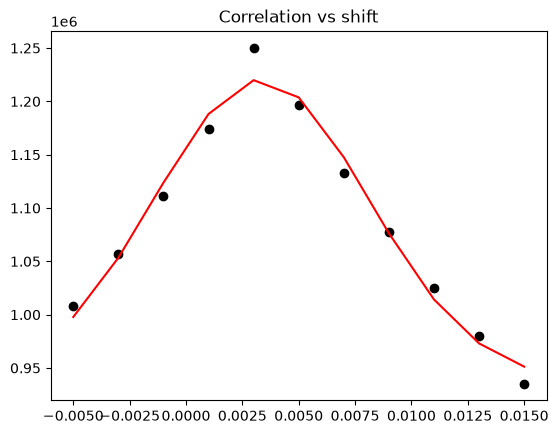

In [18]:
import matplotlib.pyplot as plt
from tttrkit.ptuio.utils import estimate_bidirectional_shift

estimated_phase = estimate_bidirectional_shift(
        reader=reader,
        config=cfg
        )

cfg.bidirectional_phase_shift, scores = estimated_phase
_, ax = plt.subplots()
ax.plot(scores[0],scores[1],color='black',marker='o',linestyle='')
ax.plot(scores[0],scores[2],color='red',linestyle='-')
ax.set_title('Correlation vs shift')
plt.show()


In [19]:

reconstructor = ImageReconstructor(
        config=cfg, 
        tcspc_channels= tcspc_bins,
        outputs=['photon_count','tcspc_histogram']
        )

for chunk in reader.iter_chunks():
    corrected_chunk = corrector.correct(chunk)
    reconstructor.update(corrected_chunk)

result = reconstructor.finalize()
image = result.photon_count
decay = result.tcspc_histogram
dtime = result.tcspc_channel * tcspc_resolution * 1e9


Reconstruction finished.


(512, 512)


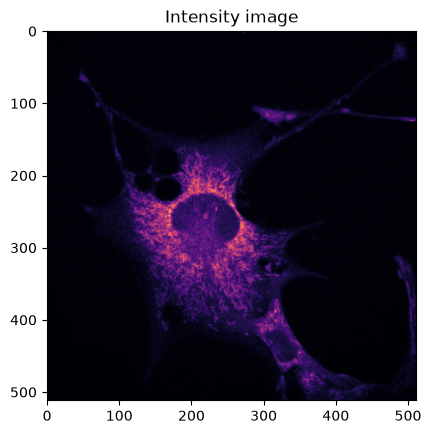

In [20]:
image_sum = image.coarsen(frame=3,sequence=1,channel=2).sum()
image_sum = image_sum.isel(frame = 0, sequence = 0, channel = 0)

print(image_sum.shape)
fig, ax = plt.subplots()
ax.imshow(image_sum,cmap='magma')
ax.set_title('Intensity image')
plt.show()

Smooth intensity image and create mask

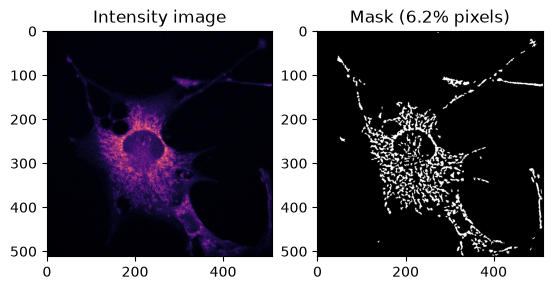

In [21]:
from skimage.filters import difference_of_gaussians, threshold_local
from skimage.morphology import remove_small_objects
import numpy as np

dog_low_sigma = 1.0       # suppress pixel-scale noise
dog_high_sigma = 3.0      # estimate the local background
dog = difference_of_gaussians(image_sum, low_sigma=dog_low_sigma, high_sigma=dog_high_sigma)

local_block_size = 51    # odd; make larger than a mitochondrion
local_offset_sigma = 0.80  # increase to reject more weak structures
local_offset = -local_offset_sigma * np.std(dog)
th = threshold_local(dog, block_size=local_block_size, method='mean', offset=local_offset)
image_mask = dog > th
image_mask = remove_small_objects(image_mask, max_size=10)

fig,ax = plt.subplots(1,2)
ax[0].imshow(image_sum,cmap='magma')
ax[0].set_title('Intensity image')
ax[1].imshow(image_mask,cmap='gray')
ax[1].set_title('Mask')
ax[1].set_title(f'Mask ({image_mask.mean():.1%} pixels)')

plt.show()



Read decay just from the masked area

In [22]:
reconstructor = ImageReconstructor(
        config=cfg, 
        tcspc_channels= tcspc_bins,
        roi_mask = image_mask,
        outputs=['tcspc_histogram']
        )

for chunk in reader.iter_chunks():
    corrected_chunk = corrector.correct(chunk)
    reconstructor.update(corrected_chunk)

result = reconstructor.finalize()
decay_masked = result.tcspc_histogram



Reconstruction finished.


Plot the decays

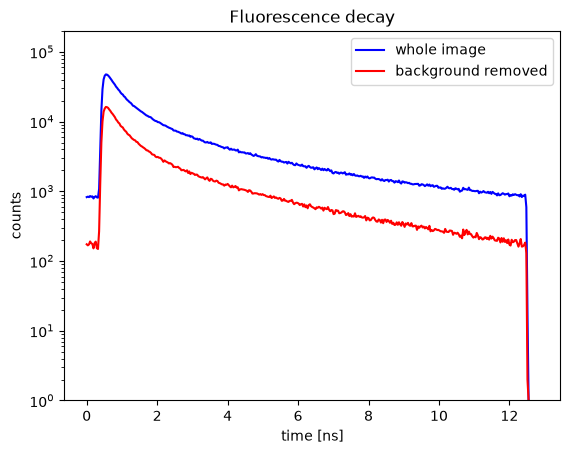

In [23]:
decay_sum = decay.coarsen(frame = 3, channel = 2).sum().squeeze()
decay_masked_sum = decay_masked.coarsen(frame = 3, channel = 2).sum().squeeze()


fig, ax = plt.subplots()
ax.semilogy(dtime.data, decay_sum.data, 'b-',label="whole image")
ax.semilogy(dtime.data, decay_masked_sum.data, 'r-',label="background removed")
ax.set_title('Fluorescence decay')
ax.set_ylabel('counts')
ax.set_xlabel('time [ns]')
ax.set_ylim(1, 2e5)
ax.legend()
plt.show()

Plot phasors

In [24]:
from tttrkit.analysis.phasor import get_phasor_from_decay

phasor_all = get_phasor_from_decay(decay=decay_sum.data,tcspc_resolution=tcspc_resolution,sync_rate=repetition_rate)
phasor_masked = get_phasor_from_decay(decay=decay_masked_sum.data,tcspc_resolution=tcspc_resolution,sync_rate=repetition_rate)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


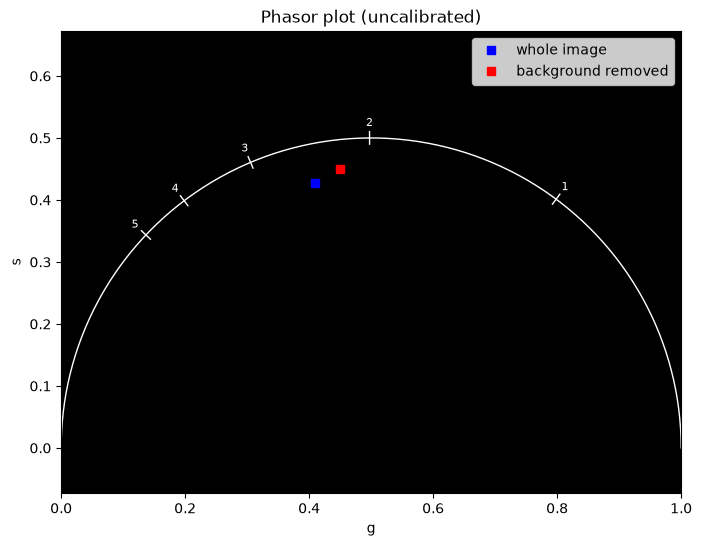

In [25]:
from tttrkit.analysis.visualization import draw_unitary_circle

fig, ax = plt.subplots(figsize=(8,6))
ax.plot(phasor_all.real,phasor_all.imag, 'bs',label = "whole image")
ax.plot(phasor_masked.real,phasor_masked.imag, 'rs', label = "background removed")
ax.set_xlabel('g')
ax.set_ylabel('s')
ax.set_title('Phasor plot (uncalibrated)')
ax.set_facecolor('black')
ax.legend()

draw_unitary_circle(ax=ax,
                    sync_rate=repetition_rate,
                    tau_max=5,
                    xlim=(0,1),
                    ylim=(0,.6),
                    )
plt.show()

# background shifts the phasor towards longer lifetime